### 1. Introducción a la Modulación OFDM

La **Modulación por División de Frecuencia Ortogonal (OFDM)** es una técnica de modulación digital multiportadora que divide un canal de banda ancha en un gran número de subcanales de banda estrecha, conocidos como **subportadoras**. La clave de OFDM reside en la **ortogonalidad** de estas subportadoras, lo que permite que sus espectros se solapen sin causar interferencia entre sí, logrando una alta eficiencia espectral.

Las principales ventajas que han convertido a OFDM en la base de estándares modernos como Wi-Fi (802.11a/g/n/ac/ax), LTE, 5G y DVB son:

*   **Robustez contra la Interferencia Intersimbólica (ISI):** Al transmitir datos en paralelo sobre muchas subportadoras lentas, la duración de cada símbolo se incrementa significativamente. Esto hace que el retardo del canal (multipath delay spread) sea una fracción pequeña de la duración del símbolo, mitigando la ISI.
*   **Eliminación de la ISI con el Prefijo Cíclico (CP):** Se introduce un intervalo de guarda (Guard Interval) antes de cada símbolo, usualmente una copia del final del propio símbolo (Prefijo Cíclico). Esto cumple dos funciones:
    1.  Absorbe la ISI del símbolo anterior, dejando la parte útil del símbolo actual intacta.
    2.  Convierte la convolución lineal del canal en una convolución circular, lo que simplifica enormemente la ecualización en el receptor.
*   **Eficiencia Computacional:** En lugar de utilizar un banco de moduladores y demoduladores analógicos (uno por subportadora), OFDM se implementa eficientemente en el dominio digital mediante la **Transformada Inversa Rápida de Fourier (IFFT)** en el transmisor y la **Transformada Rápida de Fourier (FFT)** en el receptor.
*   **Ecualización Sencilla:** Gracias al prefijo cíclico, el efecto de un canal selectivo en frecuencia se reduce a una simple multiplicación por un escalar complejo en cada subportadora. Esto permite una ecualización de un solo toque (one-tap equalizer) por subportadora, mucho más simple que los ecualizadores complejos necesarios en sistemas de portadora única.

### 2. Flujo de Transmisión y Recepción (Visión Ideal)

El proceso completo, desde los bits de entrada hasta los bits recuperados, sigue una serie de pasos bien definidos.

#### **Proceso del Transmisor OFDM:**

1.  **Generación de Bits:** Se crea una secuencia de bits binarios aleatorios como fuente de datos.
2.  **Mapeo de Símbolos:** Los bits se agrupan y se mapean a símbolos complejos (`a_k`) de una constelación digital (ej. QPSK, 16-QAM).
3.  **Construcción del Vector de Frecuencia:** Los `K` símbolos complejos se agrupan y se colocan en un vector de `N` puntos (`X_m`), rellenando las `N-K` posiciones restantes con ceros. Cada vector formará la entrada para un símbolo OFDM.
4.  **Modulación IFFT:** Se aplica la IFFT a cada vector `X_m` de `N` puntos. Esto transforma los datos del dominio de la frecuencia al dominio del tiempo, generando `N` muestras de tiempo complejas (`x_n`).
5.  **Inserción del Prefijo Cíclico (CP):** Se copian las últimas `L` muestras de la salida de la IFFT y se anteponen al bloque. El símbolo OFDM ahora tiene `N + L` muestras.
6.  **Conversión Paralelo a Serie (P/S):** Los símbolos OFDM se concatenan para formar la trama de datos a transmitir.

![Transmisor](../img/transmisor.png)

#### **Proceso del Receptor OFDM:**

1.  **Sincronización y Conversión S/P:** El receptor se sincroniza con la trama recibida y la divide en bloques de `N + L` muestras.
2.  **Eliminación del Prefijo Cíclico:** Se descartan las primeras `L` muestras de cada bloque, eliminando el CP.
3.  **Demodulación FFT:** Se aplica la FFT a las `N` muestras restantes para transformar la señal de vuelta al dominio de la frecuencia. La salida son los `N` puntos `Y_m`.
4.  **Ecualización y Extracción de Datos:** Se extraen los `K` símbolos de datos de `Y_m` y se corrige la atenuación y el desfase introducidos por el canal.
5.  **Demapeo de Símbolos:** Cada símbolo complejo recuperado se decide al punto más cercano de la constelación original.
6.  **Conversión Paralelo a Serie y Recuperación de Bits:** Los símbolos decididos se convierten de nuevo a bits, y estos se concatenan para formar la secuencia de datos recuperada.
7.  **Cálculo de BER:** Se comparan los bits transmitidos con los recuperados para medir el rendimiento.

Con estos fundamentos establecidos, procederemos a implementar cada bloque en Python.

![Receptor](../img/receptor.png)

### 0. Parámetros globales

Sea  
\[
\begin{aligned}
K      &= \text{nº de subportadoras de datos} \\
N      &= \text{tamaño de la IFFT/DFT} \\
M      &= \text{orden de modulación (QPSK → 4)} \\
\mu    &= \log_2 M \quad (\text{bits por símbolo}) \\
L      &= \text{longitud del prefijo cíclico (en muestras)} \\
f_\Delta &= \text{espaciado entre subportadoras} \\
T_{obs} &= \frac{1}{f_\Delta} \quad (\text{duración útil del símbolo}) \\
f_{samp} &= N \cdot f_\Delta \quad (\text{frecuencia de muestreo}) \\
T_{cp}   &= \frac{L}{f_{samp}} \quad (\text{duración del prefijo cíclico}) \\
T_s      &= T_{obs} + T_{cp} \quad (\text{duración total del símbolo}) \\
\end{aligned}
\]

In [53]:
# --- Importaciones de bibliotecas estándar ---
import numpy as np
import matplotlib.pyplot as plt

# --- Importaciones de nuestro paquete local ---
# Añadimos la ruta al directorio padre para que Python encuentre la carpeta 'src'
import sys
sys.path.append('../')

from src.ofdm_tf import params as p
from src.ofdm_tf import utils
from src.ofdm_tf import mapping as mp

# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
print("--- Entorno listo ---")

--- Entorno listo ---


### Bloque 1: Generador de la Secuencia de Bits de Origen

Toda comunicación digital comienza con una fuente de información. En nuestra simulación, esta fuente será una secuencia de **bits binarios** aleatorios (una sucesión de 0s y 1s), que representará los datos que queremos transmitir, como podrían ser un archivo de texto, una imagen o un fragmento de audio.

#### ¿Qué es una Subportadora y por qué es Clave en OFDM?

OFDM divide el envio de datos en muchos carriles estrechos. Cada uno de estos carriles es una **subportadora**: una onda sinusoidal de una frecuencia específica que puede transportar una pequeña cantidad de información de forma independiente.

En nuestro sistema, hemos definido `K` subportadoras de datos. Esto significa que en cada instante de tiempo (definido por la duración de un "símbolo OFDM"), transmitiremos `K` piezas de información simultáneamente, una por cada carril o subportadora.

#### ¿Cuántos Bits Necesitamos Generar?

Para llevar a cabo una simulación robusta, no basta con transmitir un solo símbolo OFDM. Necesitamos enviar una gran cantidad de ellos (`N_sym`) para poder medir el rendimiento del sistema de forma estadísticamente fiable (por ejemplo, al calcular la Tasa de Error de Bit o BER).

La cantidad total de bits que necesitamos generar se calcula multiplicando tres factores clave:

1.  **El número de símbolos OFDM que enviaremos (`N_sym`):** Es la duración de nuestra "transmisión" simulada.
2.  **El número de subportadoras de datos por cada símbolo OFDM (`K`):** Es la cantidad de "paquetes" de datos que enviamos en paralelo en cada instante.
3.  **El número de bits que caben en cada subportadora (`mu`):** Depende de la complejidad de la modulación que usemos. Para QPSK, cada subportadora transporta 2 bits de información.

Por lo tanto, la fórmula para la longitud total de la secuencia de bits es:

$$ L_{bits} = (\text{Número de Símbolos OFDM}) \times (\text{Subportadoras de Datos por Símbolo}) \times (\text{Bits por Subportadora}) $$
$$ L_{bits} = N_{sym} \times K \times \mu $$

Por ejemplo, si simulamos 10,000 símbolos OFDM, con 64 subportadoras de datos cada uno, y cada subportadora lleva 2 bits (QPSK), necesitaremos generar un total de $10,000 \times 64 \times 2 = 1,280,000$ bits.

#### Garantizando la Reproducibilidad

Para que nuestra simulación sea científica, debe ser **reproducible**. Esto significa que si volvemos a ejecutar el código, debemos obtener exactamente los mismos resultados. Para lograrlo, utilizamos un Generador de Números Aleatorios (`RNG`) con una **semilla (seed)** fija. Esto asegura que la secuencia "aleatoria" de bits que generemos sea siempre la misma en cada ejecución, lo cual es fundamental para depurar errores y validar resultados.

Parámetros de la simulación:
  - Símbolos OFDM a simular (N_sym): 10000
  - Subportadoras de datos por símbolo (K): 64
  - Bits por símbolo de constelación (mu): 2
--------------------------------------------------
Total de bits a generar: 1280000

Dimensión del vector de bits generado: (1280000,)
Primeros 20 bits generados: [1 0 0 1 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 1]


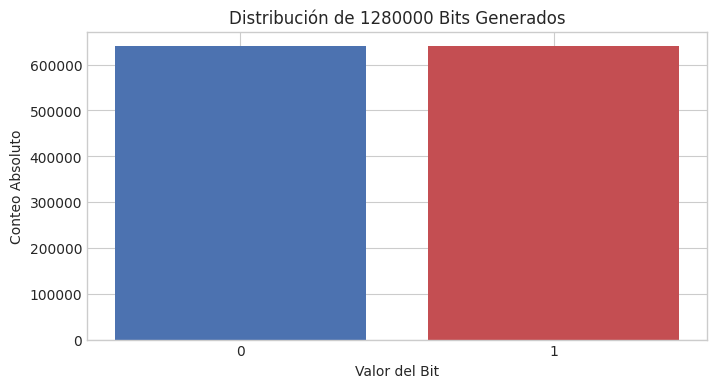


Media de los bits: 0.5001 (valor ideal: 0.5)


In [54]:
# Calcular el número total de bits a generar
n_total_bits = p.N_sym * p.K * p.mu

print(f"Parámetros de la simulación:")
print(f"  - Símbolos OFDM a simular (N_sym): {p.N_sym}")
print(f"  - Subportadoras de datos por símbolo (K): {p.K}")
print(f"  - Bits por símbolo de constelación (mu): {p.mu}")
print(f"--------------------------------------------------")
print(f"Total de bits a generar: {n_total_bits}")

# Generar la secuencia de bits aleatoria usando el RNG de params
bits_tx = p.RNG.integers(low=0, high=2, size=n_total_bits)

# --- Verificación ---
print(f"\nDimensión del vector de bits generado: {bits_tx.shape}")
print(f"Primeros 20 bits generados: {bits_tx[:20]}")

# Comprobar que la distribución es aproximadamente uniforme
plt.figure(figsize=(8, 4))
counts = np.bincount(bits_tx)
plt.bar([0, 1], counts, color=['#4c72b0', '#c44e52'])
plt.title(f'Distribución de {n_total_bits} Bits Generados')
plt.xticks([0, 1])
plt.xlabel('Valor del Bit')
plt.ylabel('Conteo Absoluto')
plt.show()

media_bits = np.mean(bits_tx)
print(f"\nMedia de los bits: {media_bits:.4f} (valor ideal: 0.5)")
assert 0.49 < media_bits < 0.51, "La distribución de bits no parece uniforme."

### Bloque 2: Mapeo de Bits a Símbolos de Constelación ($a_k$)

En el bloque anterior, generamos una larga secuencia de unos y ceros. Sin embargo, estos bits son una representación abstracta de la información. Para poder transmitirlos a través de un medio físico (como el aire o un cable), necesitamos convertirlos en una **señal analógica**. Este proceso se llama **modulación**.

La modulación consiste en variar una propiedad de una onda portadora (como su amplitud, fase o frecuencia) de acuerdo con la información que queremos enviar. En OFDM, en lugar de modular una sola portadora, modulamos `K` subportadoras de datos simultáneamente. Los símbolos complejos generados en este paso, denotados como $a_k$ en el paper, son los que determinarán la amplitud y fase de cada una de estas `K` subportadoras.

#### ¿Qué es un Símbolo de Constelación?

En lugar de enviar un bit a la vez, los sistemas de comunicación modernos agrupan varios bits para formar un **símbolo**. Un símbolo es un estado único de la señal que representa un grupo específico de bits. La colección de todos los símbolos posibles se llama **constelación**.

Visualizamos esta constelación en un **diagrama de constelación**, que es un gráfico en el plano complejo (también conocido como plano I/Q, por "In-phase" y "Quadrature"). Cada punto en este diagrama representa un símbolo único, definido por una amplitud (su distancia al origen) y una fase (su ángulo con el eje real). En nuestro caso, estos son los símbolos $a_k$.

#### Modulación por Desplazamiento de Fase en Cuadratura (QPSK)

Para nuestra simulación, utilizaremos **QPSK (Quadrature Phase Shift Keying)**, una de las formas más comunes de modulación digital.

*   **Quaternary (Cuaternaria):** Significa que hay 4 símbolos posibles en la constelación. Como $2^2 = 4$, cada símbolo QPSK puede representar un grupo de **2 bits** (`mu = 2`).
*   **Phase Shift (Desplazamiento de Fase):** La información se codifica únicamente en la fase de la onda portadora. En QPSK, se utilizan cuatro fases distintas, separadas por 90 grados (45°, 135°, 225°, 315°). La amplitud de todos los símbolos es la misma.
*   **Keying (Manipulación):** Es el proceso de cambiar (o "manipular") la fase de la portadora según el grupo de bits de entrada.

#### El Proceso de Mapeo y la Codificación Gray

El mapeo es el proceso de asignar cada posible grupo de bits a un punto específico de la constelación. Para QPSK, asignamos cada par de bits a uno de los cuatro puntos. Una asignación inteligente es crucial, y para ello se utiliza la **codificación Gray**.

**¿Por qué es importante la codificación Gray?**
En un canal real, el ruido puede hacer que el receptor se equivoque y confunda un símbolo con uno adyacente en la constelación. Con la codificación Gray, los símbolos adyacentes **difieren en un solo bit**. Esto significa que el error más probable (confundir un símbolo con su vecino) resultará en **un solo bit erróneo** en lugar de dos, mejorando significativamente el rendimiento del sistema (la BER).

Nuestra tabla de mapeo QPSK con codificación Gray es la siguiente:

| Par de Bits (b₁, b₂) | Símbolo Complejo ($a_k$)               | Coordenadas (Real, Imag) |
| :------------------: | :--------------------------------: | :-----------------------: |
|          10          | $\frac{1}{\sqrt{2}} (1 - j)$        |         (+1, -1)          |
|          11          | $\frac{1}{\sqrt{2}} (-1 - j)$       |         (-1, -1)          |
|          01          | $\frac{1}{\sqrt{2}} (-1 + j)$       |         (-1, +1)          |
|          00          | $\frac{1}{\sqrt{2}} (1 + j)$        |         (+1, +1)          |

**Fórmula de Mapeo y Normalización:**
Este mapeo se puede implementar eficientemente con una única fórmula matemática. Para un par de bits $(b_1, b_2)$:

$$ a_k = \frac{(1 - 2b_1) + j(1 - 2b_2)}{\sqrt{2}} $$

*   El término (1 - $ 2b_i $) es un truco elegante para convertir un bit `0` en `+1` y un bit `1` en `-1`.
*   El factor `1/√2` es el **factor de normalización**. Se utiliza para asegurar que la **energía promedio por símbolo**:

$$
E_s = |a_k|^2 = a^2 + b^2 = \Bigl(\frac{1}{\sqrt{2}}\Bigr)^2 + \Bigl(\frac{1}{\sqrt{2}}\Bigr)^2 = \frac{1}{2} + \frac{1}{2} = 1.
$$

Esto es fundamental para que los cálculos de relación señal-ruido y la comparación de rendimiento entre esquemas de modulación sean justos y consistentes.


#### ¿Por qué normalizar a $ E_s $ = 1\?

1. **Define la relación señal-ruido de forma directa:**

   $$
   \mathrm{SNR} = \frac{E_s}{N_0} = \frac{1}{N_0}.
   $$

2. **Al expresarlo en decibelios:**

   $$
   \mathrm{SNR}_{\mathrm{dB}}
   = 10 \,\log_{10}\!\Bigl(\frac{E_s}{N_0}\Bigr)
   = -\,10 \,\log_{10}(N_0),
   $$

   lo cual facilita ver el efecto del ruido $ N_0 $ como un desplazamiento aditivo en dB, sin depender de la potencia absoluta de la señal.

3. **Simplifica la conversión a energía por bit:**  
   Como cada símbolo codifica $ log_2 $ 4 = 2 bits,

   $$
   E_b = \frac{E_s}{2} = \frac{1}{2}
   \quad\Longrightarrow\quad
   \frac{E_b}{N_0} = \frac{1}{2\,N_0},
   $$

   unificando así las curvas de BER de cualquier esquema de modulación.

In [55]:
# Paso 1: Reformatear la secuencia de bits en grupos de 'mu' bits.
# La dimensión resultante será (N_total_de_simbolos, mu).
bits_reshaped = bits_tx.reshape(-1, p.mu)

# --- Verificación ---
print(f"Dimensiones de la matriz de bits agrupados: {bits_reshaped.shape}")
print(f"Número de grupos de bits (símbolos a mapear): {bits_reshaped.shape[0]}")
print(f"Bits por grupo (mu): {bits_reshaped.shape[1]}")
print("\nPrimeros 5 grupos de bits:")
print(bits_reshaped[:5])

Dimensiones de la matriz de bits agrupados: (640000, 2)
Número de grupos de bits (símbolos a mapear): 640000
Bits por grupo (mu): 2

Primeros 5 grupos de bits:
[[1 0]
 [0 1]
 [0 0]
 [1 0]
 [0 1]]


In [56]:
# Paso 2: Mapear cada par de bits (b1, b2) a un símbolo QPSK con Gray mapping
# bits_reshaped tiene forma (n_símbolos, 2): columna 0 = b1 (MSB), columna 1 = b2 (LSB)
# Con Gray mapping:
#   (b1,b2) = (1,0) →  +1 – j
#   (b1,b2) = (1,1) →  –1 – j
#   (b1,b2) = (0,1) →  –1 + j
#   (b1,b2) = (0,0) →  +1 + j
# Fómula eficiente: real = 1–2·b2, imag = 1–2·b1, luego normalizamos por √2

ak_symbols_flat = (1 - 2*bits_reshaped[:, 1]) \
                + 1j*(1 - 2*bits_reshaped[:, 0])

# Paso 3: Normalizar para energía promedio = 1
ak_symbols_flat /= np.sqrt(2)

# --- Verificación ---
print(f"\nDimensiones del vector de símbolos a_k: {ak_symbols_flat.shape}")
print("\nPrimeros 5 símbolos a_k generados (redondeados):")
print(np.round(ak_symbols_flat[:5], 3))


Dimensiones del vector de símbolos a_k: (640000,)

Primeros 5 símbolos a_k generados (redondeados):
[ 0.707-0.707j -0.707+0.707j  0.707+0.707j  0.707-0.707j -0.707+0.707j]


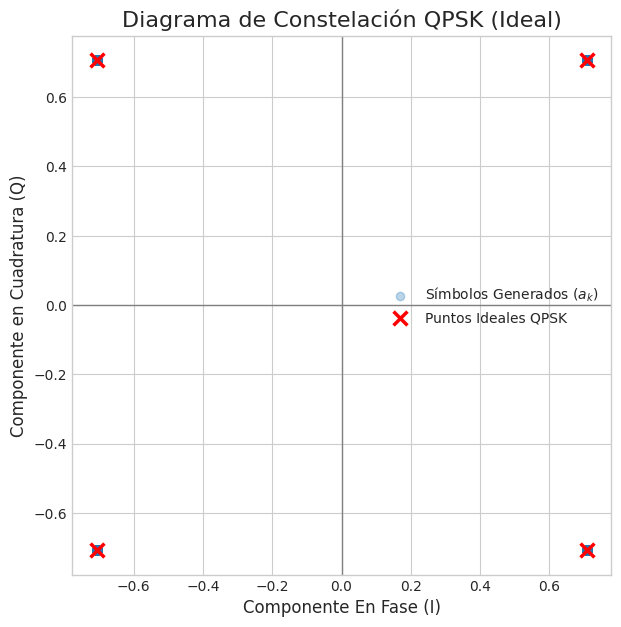

In [57]:
# Crear un scatter plot de la constelación ideal
# Estos son los 4 puntos que deberían existir
bits_b1 = np.array([0, 0, 1, 1])  # Primera columna de la tabla (los b₁)
bits_b2 = np.array([0, 1, 1, 0])  # Segunda columna de la tabla (los b₂)

ideal_constellation = ( (1 - 2*bits_b2) + 1j*(1 - 2*bits_b1) ) / np.sqrt(2)
# if 0 => +1
# if 1 => -1

plt.figure(figsize=(7, 7))

# Graficamos una muestra de los símbolos generados para no sobrecargar el gráfico
# Usamos alpha para ver la densidad de puntos
plt.scatter(np.real(ak_symbols_flat[:5000]), np.imag(ak_symbols_flat[:5000]), 
            alpha=0.3, label='Símbolos Generados ($a_k$)')

# Superponemos los puntos ideales para verificar
plt.scatter(np.real(ideal_constellation), np.imag(ideal_constellation), 
            color='red', marker='x', s=100, linewidth=2.5, label='Puntos Ideales QPSK')

plt.title('Diagrama de Constelación QPSK (Ideal)', fontsize=16)
plt.xlabel('Componente En Fase (I)', fontsize=12)
plt.ylabel('Componente en Cuadratura (Q)', fontsize=12)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.legend()
plt.axis('square') # Asegura que los ejes tengan la misma escala
plt.show()

### La Energía del Símbolo

Un concepto fundamental en comunicaciones digitales es la **energía por símbolo**, denotada como $E_s$. Físicamente, representa la energía que se gasta para transmitir un único símbolo a través del canal durante su intervalo de tiempo.

Matemáticamente, para un símbolo complejo $s = I + jQ$, su energía se calcula como el cuadrado de su magnitud (o módulo):

$$ E_s = |s|^2 = (\sqrt{I^2 + Q^2})^2 = I^2 + Q^2 $$

En un diagrama de constelación, esto es simplemente el cuadrado de la distancia del punto al origen.

In [58]:
# Calcular la energía promedio de todos los símbolos generados
# La energía de un símbolo 's' es |s|^2
average_energy = np.mean(np.abs(ak_symbols_flat)**2) # .mean saca el valor medio de las energias

print(f"Energía promedio por símbolo calculada: {average_energy:.4f}")
print(f"Energía promedio por símbolo esperada: {p.Es}")

# Usamos np.isclose para comparar números de punto flotante de forma segura
assert np.isclose(average_energy, p.Es), "La normalización de la energía no es correcta."

print("\n¡Verificación superada! La constelación está correctamente generada y normalizada.")

Energía promedio por símbolo calculada: 1.0000
Energía promedio por símbolo esperada: 1.0

¡Verificación superada! La constelación está correctamente generada y normalizada.


### Bloque 3: Mapeo a Subportadoras de Datos

En el anterior bloque convertimos nuestra secuencia de bits en una larga lista de símbolos complejos QPSK ($a_k$). Ahora, nuestro objetivo es tomar estos símbolos y colocarlos en las "ranuras" correctas de un vector más grande, el vector de frecuencia `X`, que será la entrada a nuestro bloque de IFFT.
Este proceso es fundamental porque la **posición** de cada símbolo $a_k$ en el vector `X` determina en qué **frecuencia de subportadora** se transmitirá esa información. Nuestra estrategia, es crear una señal de **paso bajo compleja (complex baseband)**.

**Referencia del Paper:** Sección 2, principalmente Step 1 y Step 3 (Págs. 9, 16).

Hasta ahora, tenemos los símbolos de datos $a_k$. El paper de Lindell explica en la **Ecuación (1.13)** que una señal OFDM es, en esencia, la suma de $K$ señales QPSK, cada una modulada sobre una subportadora de frecuencia $f_k$:
$$
\text{OFDM signal}(t) = g_{rec}(t) \text{Re} \left\{ \left( \sum_{k=0}^{K-1} a_k e^{j2\pi g_k f_\Delta t} \right) e^{j2\pi f_{rc} t} \right\}
$$

El término entre paréntesis, $x(t) = \sum_{k=0}^{K-1} a_k e^{j2\pi g_k f_\Delta t}$, es lo que Lindell llama la **señal de paso bajo compleja equivalente (equivalent complex baseband signal)**, definida en la **Ecuación (2.3)**. Nuestro objetivo es **construir esta señal $x(t)$ de forma digital y eficiente**.

La clave de la eficiencia de OFDM es usar la **Transformada Inversa Discreta de Fourier (IDFT)** para generar las muestras de $x(t)$. La IDFT es la implementación algorítmica de esa suma de exponenciales complejas. La **Ecuación (2.16)** nos da la definición de la IDFT de `N` puntos:
$$
x_n = \frac{1}{N} \sum_{m=0}^{N-1} X_m e^{j2\pi mn/N}
$$

Para que la salida $x_n$ se corresponda con nuestra señal deseada, debemos construir cuidadosamente el vector de entrada $X_m$. Este vector $X_m$ representa las amplitudes complejas en cada una de las $N$ posibles "frecuencias discretas" (o "bins") de la IFFT. El Bloque 3 consiste en construir este vector $X_m$.

#### Bloque 3.1: Organización de los Datos

Antes de construir el vector $X_m$ para un único símbolo OFDM, debemos organizar nuestra larga secuencia de símbolos $a_k$ (`ak_symbols_flat`). La vamos a agrupar en una matriz donde cada fila contendrá los $K$ símbolos de datos necesarios para un único símbolo OFDM.

In [59]:
# Bloque 3.1: Agrupar símbolos y preparar matriz de entrada IFFT

# Agrupamos la lista plana de símbolos en una matriz (N_sym, K)
# donde cada fila contiene los K símbolos para un símbolo OFDM.
ak_matrix = ak_symbols_flat.reshape(p.N_sym, p.K)

# Inicializamos la matriz de entrada de la IFFT con ceros complejos.
# Esta matriz tendrá dimensiones (N_sym, N).
X_matrix = np.zeros((p.N_sym, p.N), dtype=complex)

# --- Verificación ---
print(f"Dimensiones de la matriz de símbolos de datos (ak_matrix): {ak_matrix.shape}")
print(f"Dimensiones de la matriz de entrada a la IFFT (X_matrix): {X_matrix.shape}")

Dimensiones de la matriz de símbolos de datos (ak_matrix): (10000, 64)
Dimensiones de la matriz de entrada a la IFFT (X_matrix): (10000, 80)


**Explicación:** Esta matriz `ak_matrix` es nuestra reserva de datos. La fila `i` de esta matriz contiene el conjunto de símbolos $\{a_0, a_1, \dots, a_{K-1}\}$ que se usarán para construir el `i`-ésimo símbolo OFDM.

#### Bloque 3.2: Construcción del Vector de Frecuencia $X_m$

**Referencia del Paper:** Ecuaciones (2.19) a (2.21) y el Ejemplo en la pág. 16 para K=8, N=12.

Ahora viene el paso crucial. Para cada fila de `ak_matrix`, construiremos un vector $X_m$ de tamaño $N$. Lindell nos muestra cómo hacerlo para crear una señal de paso bajo. El espectro de una señal de paso bajo se agrupa alrededor de la frecuencia 0 Hz (DC). En el mundo discreto de la DFT/IDFT, el índice $m=0$ corresponde a DC. Las frecuencias positivas bajas ($f_\Delta, 2f_\Delta, \dots$) corresponden a los índices $m=1, 2, \dots$, mientras que las frecuencias negativas ($-f_\Delta, -2f_\Delta, \dots$) se mapean a los índices finales del vector ($m=N-1, N-2, \dots$).

La estrategia es:
1.  **Asignar símbolos $a_k$ a las subportadoras de datos**: Las $K$ subportadoras de datos se dividen en dos grupos: las que corresponden a frecuencias positivas y las que corresponden a frecuencias negativas.
2.  **Dejar las subportadoras de guarda a cero**: Los `N-K` "bins" restantes del vector $X_m$ se rellenan con ceros. Esto incluye la componente DC (índice 0) y una banda de guarda central, que ayuda a relajar los requisitos de los filtros en un sistema real.

Esto implementa directamente las ecuaciones del paper, que establecen la relación entre los símbolos de datos $a_k$ y los valores del vector de frecuencia $X_m$:

$$
X_m \propto a_{k} \quad \text{donde } k \text{ se relaciona con } m
$$

El paper introduce los índices $g_k$ y $k_{rc}$ para formalizar esta relación. Nuestra implementación modular en `mapping.py` calcula estos mapeos de forma programática.

<div align="center">
  <img src="../img/mapping.png" alt="Mapeo Subportadoras" width="500px"/>
</div>


In [60]:
# 1. Usamos nuestro módulo 'mapping' para obtener los índices pre-calculados.
# Esto encapsula la lógica de las Ecuaciones (2.19)-(2.21).
subcarriers_pos = mp.DATA_CARRIERS_POS
subcarriers_neg = mp.DATA_CARRIERS_NEG

# X_m esta inicializada arriba

# 2. Dividimos los K símbolos de cada símbolo OFDM en dos mitades.
# La primera mitad corresponde a las frecuencias positivas.
symbols_pos = ak_matrix[:, :len(subcarriers_pos)]
# La segunda mitad corresponde a las frecuencias negativas.
symbols_neg = ak_matrix[:, len(subcarriers_pos):]

# 3. Asignamos los símbolos a las subportadoras correspondientes en la matriz X.
# Esto se hace para los N_sym símbolos OFDM de una sola vez.
X_matrix[:, subcarriers_pos] = symbols_pos
X_matrix[:, subcarriers_neg] = symbols_neg

# --- Verificación ---
print("Construcción de la matriz X completada.")
print(f"Dimensiones de X_matrix: {X_matrix.shape}")

Construcción de la matriz X completada.
Dimensiones de X_matrix: (10000, 80)


**Explicación:** Cada fila de `X_matrix` es ahora un vector $X_m$ como el descrito por Lindell. Contiene nuestros $K$ símbolos de datos en las posiciones correctas y ceros en el resto, listo para ser procesado por la IFFT.

#### Bloque 3.3: Visualización del Espectro de Frecuencia

**Referencia del Paper:** Figura 3b (pág. 10) y Figura 6 (pág. 17).

La mejor forma de validar nuestro mapeo es visualizarlo. Graficaremos la magnitud de una de las filas de `X_matrix` (el espectro del primer símbolo OFDM). Este gráfico debe parecerse a la **Figura 3b** del paper, que muestra la transformada de Fourier $X_a(f)$ de la señal de paso bajo. Nuestro gráfico será la versión discreta de esa figura.

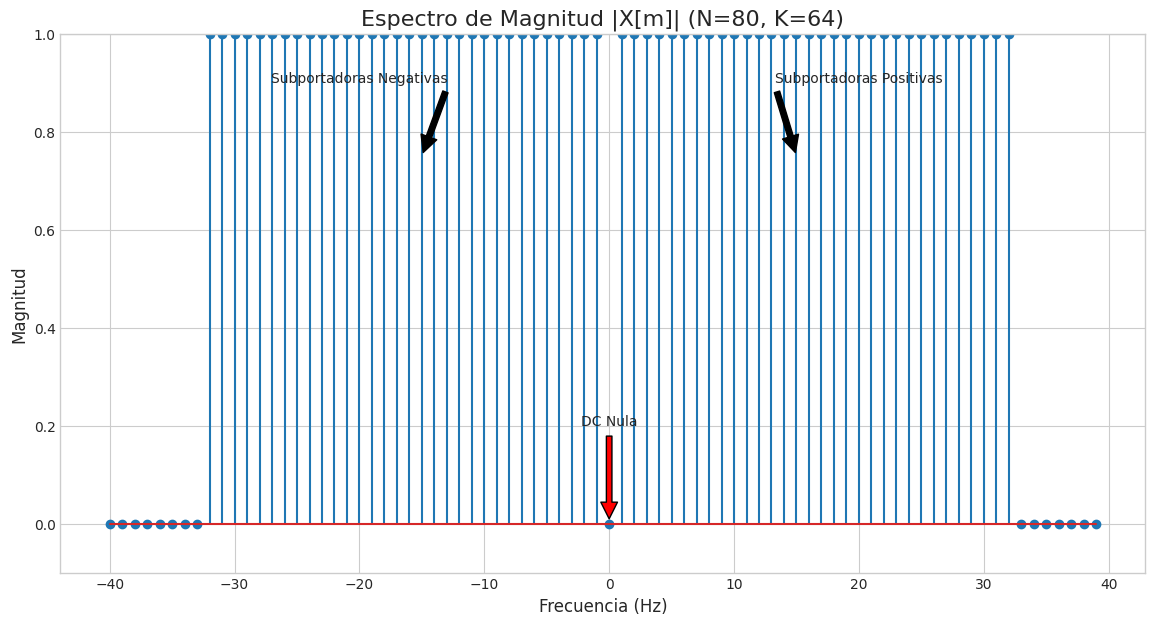

In [61]:
# Extraemos la primera fila de X_matrix para el gráfico
X_primer_simbolo = X_matrix[0, :]

# Para una visualización más intuitiva, centramos el espectro en 0.
# El eje de frecuencias normalizadas se calcula con np.fft.fftfreq.
freq_axis = np.fft.fftshift(np.fft.fftfreq(p.N, d=1/p.fsamp)) # Frecuencia en Hz
# Y el espectro se reordena con np.fft.fftshift para que DC quede en el centro.
X_shifted = np.fft.fftshift(np.abs(X_primer_simbolo))

plt.figure(figsize=(14, 7))
plt.stem(freq_axis, X_shifted)

plt.title(f'Espectro de Magnitud |X[m]| (N={p.N}, K={p.K})', fontsize=16)
plt.xlabel('Frecuencia (Hz)', fontsize=12)
plt.ylabel('Magnitud', fontsize=12)
plt.grid(True)
plt.ylim(bottom=-0.1, top=1.0) # Ajuste para mejor visualización
plt.annotate(f'Subportadoras Positivas', xy=(15, 0.75), xytext=(20, 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
plt.annotate(f'Subportadoras Negativas', xy=(-15, 0.75), xytext=(-20, 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
plt.annotate('DC Nula', xy=(0, 0), xytext=(0, 0.2),
             arrowprops=dict(facecolor='red', shrink=0.05), ha='center')
plt.show()

**Análisis del Gráfico y Conexión con la Teoría:**

*   **Estructura del Espectro:** El gráfico muestra claramente dos bloques de energía (donde están nuestros símbolos $a_k$) separados por una región de ceros. Esta es la representación visual de nuestra señal de paso bajo.
*   **Simetría:** La energía está agrupada simétricamente alrededor de la frecuencia 0 Hz (DC).
*   **Banda de Guarda:** La zona central sin energía es la banda de guarda. Su propósito es práctico: en un sistema real, los filtros analógicos no son perfectos. Esta banda de guarda asegura que la energía de las frecuencias positivas no se "filtre" y contamine a las negativas (y viceversa) después de la conversión a RF.
*   **DC Nula:** La subportadora en 0 Hz está vacía (magnitud cero). Esto es una práctica de diseño robusta para evitar la interferencia de "DC offset" en el hardware del receptor.
